In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib.gridspec as gridspec
import matplotlib as mpl
mpl.style.use('classic')

from astropy.table import Table, vstack
from astropy import units as u
from astropy.constants import G
from astropy.io import ascii

from scipy.integrate import quad
from scipy.interpolate import CubicSpline,make_interp_spline

import os

%matplotlib inline

# note: 1 bar = 10^6 erg/cm3

In [2]:
rsun_to_cm = u.solRad.to(u.cm)
print(rsun_to_cm)

69570000000.0


In [55]:
#eos_names = ['CD21+AQUA_orig_meos_implementation']#,'CMS19_orig_meos_implementation','CMS19_TC_s=1','CD21_Y0275']
eos_names = ['CD21_Y0275']

comps = ['platowg']

Minit = np.atleast_1d(np.array((1.0)))

age = 5.0e9
agestr = str(np.round(age/1.e9, 1))
print(agestr)

#atm = ['irradiatedgrey','customatm']
atm = ['customatm']

eos_colors = ['b','r','g']#,'m']
#atm_ls = ['-','--']
atm_ls = ['--']

5.0


# My models

CD21_Y0275 customatm
7.213278976215343


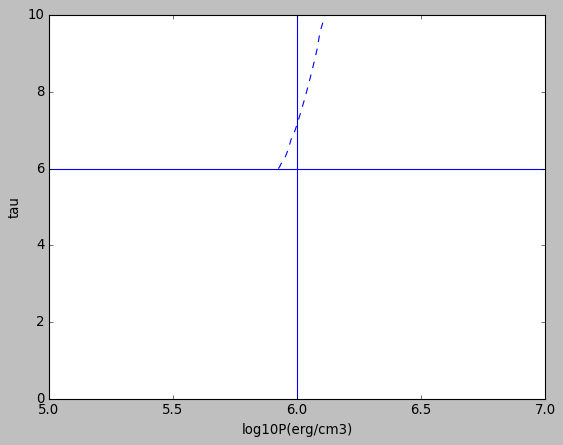

In [71]:
r = 2.0

fig, ax = plt.subplots(1,1,figsize=(8,6))

for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        profile =Table.read("../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/planet_1.0_Mj_{1}_Rj_platowg_{2}.terminationprofile".format(e,r,a), format="ascii", header_start=4, data_start=5)

        print(e,a)
        ax.plot(profile['logP'],profile['tau'],color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))
        #print(np.min(profile['tau']))

        P_1bar_idx = np.argmin(np.abs(np.array(profile['pressure']) - 1.e6))
        P_1bar = np.array(profile['pressure'])[P_1bar_idx]
        zone_1bar = np.array(profile['zone'])[P_1bar_idx]
        T_1bar = np.array(profile['temperature'])[P_1bar_idx]
        tau_1bar = np.array(profile['tau'])[P_1bar_idx]
        print(tau_1bar)

ax.set_xlabel('log10P(erg/cm3)')
ax.set_ylabel('tau')

ax.set_xlim(5,7)
ax.set_ylim(0,10)
ax.axvline(6)
ax.axhline(6)
plt.show()

In [72]:
(6*7)/6.197277147000204

6.777169876988659

# Simon's models

In [73]:
simon_history = Table.read("./simon_MESA_runs/mesa_evolution_jupiter_benchmark.data", format="ascii", header_start=0, data_start=1)
print(simon_history)
simon_profile = Table.read("./simon_MESA_runs/mesa_interior_jupiter_benchmark.data", format="ascii", header_start=0, data_start=1)
print(simon_profile)


simon_t200mask = (simon_profile['T_int(K)'] == 2.00058942e+02) # 3.35e8 yr
simon_t100mask = (simon_profile['T_int(K)'] == 1.00013930e+02) # 3.88e9 yr


Model_number    Age(yr)     T_int(K)  Luminosity(erg/s)   Radius(cm) 
------------ ------------- ---------- ----------------- -------------
           0      114.4534 1307.34309    6.14472898e+29 17181474600.0
           1    251.797479 1306.98075    6.13434785e+29 17176475000.0
           2    416.610375 1306.54695    6.12194053e+29 17170491700.0
           3     614.38585 1306.02786    6.10712329e+29 17163335100.0
           4    851.716419 1305.40704    6.08944476e+29 17154780500.0
           5     1136.5131 1304.66505    6.06837616e+29 17144562600.0
           6    1478.26912 1303.77893     6.0433011e+29 17132369100.0
           7    1888.37635 1302.72166    6.01350538e+29 17117833600.0
           8    2380.50502 1301.46161    5.97816747e+29 17100528400.0
           9    2971.05942 1299.96186    5.93635068e+29 17079957000.0
         ...           ...        ...               ...           ...
        1068  9915431950.0 66.7918742    6.95343874e+23  7002301020.0
        1069  992543

# Luke's CESAM model


In [74]:
cesam = Table.read("./CESAM_structure.dat", format="ascii", header_start=0, data_start=1)
print(cesam)

cesam_t200mask = (cesam['T_int[K]'] == 1.98062966e+02)
cesam_t100mask = (cesam['T_int[K]'] == 9.77704346e+01)

cesam_age_jump = np.array(cesam['age[Myr]'])[1:] - np.array(cesam['age[Myr]'])[0:-1]
print(cesam_age_jump)
cesam_age_jump_mask = (cesam_age_jump > 0.)
cesam_outermost_mask = np.zeros_like(np.array(cesam['age[Myr]'])).astype(int)
cesam_outermost_mask[1:][cesam_age_jump_mask] = 1
cesam_outermost_mask = (cesam_outermost_mask == 1)

age[Myr]  T_int[K]    P[dyn/cm^2]       T[K]        R[cm]      rho[g/cm^3]  
-------- ---------- ---------------- ---------- ------------- --------------
     0.0    1230.53        1000000.0 1840.08181 13866730900.0 1.52541332e-05
     0.0    1230.53       1045976.72 1861.57335 13862437600.0 1.57707192e-05
     0.0    1230.53       1094104.46 1883.25196 13858093500.0 1.63058135e-05
     0.0    1230.53       1144479.03 1905.12913 13853698700.0 1.68598445e-05
     0.0    1230.53       1197237.35 1927.15675 13849250300.0 1.74344282e-05
     0.0    1230.53       1252523.23 1949.29041 13844745600.0  1.8031324e-05
     0.0    1230.53       1310457.57 1971.53465 13840184700.0 1.86514241e-05
     0.0    1230.53       1371141.08 1993.93169 13835569500.0 1.92947431e-05
     0.0    1230.53       1434689.96 2016.50545 13830900800.0 1.99615697e-05
     0.0    1230.53       1501264.17 2039.22608 13826176700.0 2.06533436e-05
     ...        ...              ...        ...           ...            ...

# Loop through profiles and make a single profile file with age as a column

In [75]:
def concatenate_profiles(profile_directory, profile_prefix, Tirr=110.0):

    profiles = [f for f in os.listdir(profile_directory) if profile_prefix in f]
    profnumbers = []
    for prof in profiles:
        profnumber = prof.split("profile")[1].split(".data")[0]
        
        profnumbers.append(int(profnumber))

    profnumbers = np.sort(np.array(profnumbers))
    
    for i, n in enumerate(profnumbers):
        profile = profile_directory + "{0}_profile{1}.data".format(profile_prefix,n)
        profile_header = Table.read(profile, format="ascii", header_start=1, data_start=2,data_end=3)
        profile_age = profile_header['star_age'][0]
        model_number = profile_header['model_number'][0]
        
        profile_data =  Table.read(profile, format="ascii", header_start=4, data_start=5)
        profile_data['age(yr)'] = profile_age * np.ones_like(profile_data['zone'])
        profile_data['model_number'] = model_number * np.ones_like(profile_data['zone'])

        P_1bar_idx = np.argmin(np.abs(np.array(profile_data['pressure']) - 1.e6))
        P_1bar = np.array(profile_data['pressure'])[P_1bar_idx]
        zone_1bar = np.array(profile_data['zone'])[P_1bar_idx]
        T_1bar = np.array(profile_data['temperature'])[P_1bar_idx]
        tau_1bar = np.array(profile_data['tau'])[P_1bar_idx]

        gamma = 1.


        # solve Guillot 2010 eq 49 for T_int, given Tbar = T_1bar, Teq = Tirr
        def E2_integrand(t,tau_,gamma_):
            return t**-2 * np.exp(-1 * t * tau_ * gamma_)
            
        E2_integral = quad(E2_integrand, 1, np.inf, args=(tau_1bar, gamma))[0]

        term2 = (3./4.)*Tirr**4 * ( (2./3.) + (2./(3*gamma))*(1 + ((gamma*tau_1bar)/2. -1)*np.exp(-1*gamma*tau_1bar)) + ((2*gamma)/3.)*(1. - tau_1bar**2/2)*E2_integral ) 

        T_int = (((T_1bar**4 - term2)*(4./3.))/((2./3.) + tau_1bar))**(1./4.)
        
        # below would only be correct if tau = 6
        #T_int = ((T_1bar**4 - Tirr**4)/5.)**(1./4.)
        
        profile_data['P_1bar'] = P_1bar * np.ones_like(profile_data['zone'])
        profile_data['zone_1bar'] = zone_1bar * np.ones_like(profile_data['zone'])
        profile_data['T_1bar'] = T_1bar * np.ones_like(profile_data['zone'])
        profile_data['T_int'] = T_int * np.ones_like(profile_data['zone'])

        
        if i==0:
            full_profile_table = profile_data
    
        else:
            full_profile_table = vstack([full_profile_table, profile_data])

    return full_profile_table

In [76]:
def find_T_int(profile_history, T_int):

    tdiff = np.abs(np.array(profile_history['T_int']) - T_int)
    min_tdiff = np.min(tdiff)
    min_idxs = (tdiff == min_tdiff)

    return min_idxs

In [77]:
desired_log10P = np.arange(6.,13.5,0.05)

cesam_t100_interp_logT = np.interp(desired_log10P, np.log10(cesam['P[dyn/cm^2]'])[cesam_t100mask], np.log10(cesam['T[K]'])[cesam_t100mask])
simon_t100_interp_logT = np.interp(desired_log10P, simon_profile['logP(erg/cm3)'][simon_t100mask], simon_profile['logT(K)'][simon_t100mask])

cesam_t200_interp_logT = np.interp(desired_log10P, np.log10(cesam['P[dyn/cm^2]'])[cesam_t200mask], np.log10(cesam['T[K]'])[cesam_t200mask])
simon_t200_interp_logT = np.interp(desired_log10P, simon_profile['logP(erg/cm3)'][simon_t200mask], simon_profile['logT(K)'][simon_t200mask])


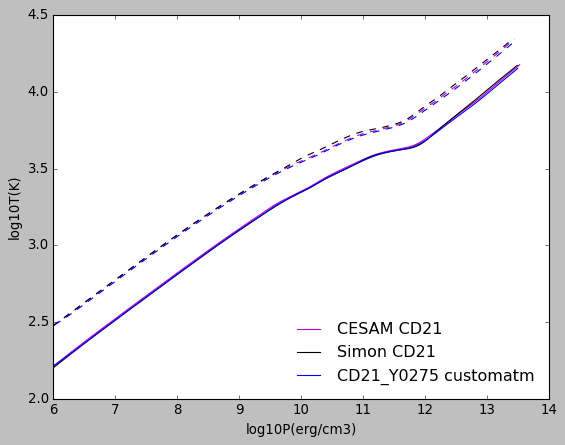

In [78]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(np.log10(cesam['P[dyn/cm^2]'])[cesam_t200mask],np.log10(cesam['T[K]'])[cesam_t200mask],'m--')
ax.plot(np.log10(cesam['P[dyn/cm^2]'])[cesam_t100mask],np.log10(cesam['T[K]'])[cesam_t100mask],'m-',label='CESAM CD21')

ax.plot(simon_profile['logP(erg/cm3)'][simon_t200mask],simon_profile['logT(K)'][simon_t200mask],'k--')
ax.plot(simon_profile['logP(erg/cm3)'][simon_t100mask],simon_profile['logT(K)'][simon_t100mask],'k-',label='Simon CD21')

for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        profile_history = concatenate_profiles(profile_directory="../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/LOGS/".format(e),profile_prefix="planet_5.0Gyr_1.0_Mj_{0}_Rj_platowg_{1}".format(r,a))
        #print(profile_history)

        t100_idxs = find_T_int(profile_history, T_int=100)
        t200_idxs = find_T_int(profile_history, T_int=200)

        ax.plot(profile_history['logP'][t200_idxs],profile_history['logT'][t200_idxs],color=eos_colors[i],ls='--')
        ax.plot(profile_history['logP'][t100_idxs],profile_history['logT'][t100_idxs],color=eos_colors[i],ls='-',label='{0} {1}'.format(e,a))

ax.set_xlabel('log10P(erg/cm3)')
ax.set_ylabel('log10T(K)')
ax.set_xlim(6,14)

ax.legend(loc='lower right',frameon=False)
plt.show()

      T_int      
-----------------
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
              ...
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
99.33016233509856
Length = 874 rows
      T_int       
------------------
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
               ...
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
203.72663538577422
Length = 862 rows


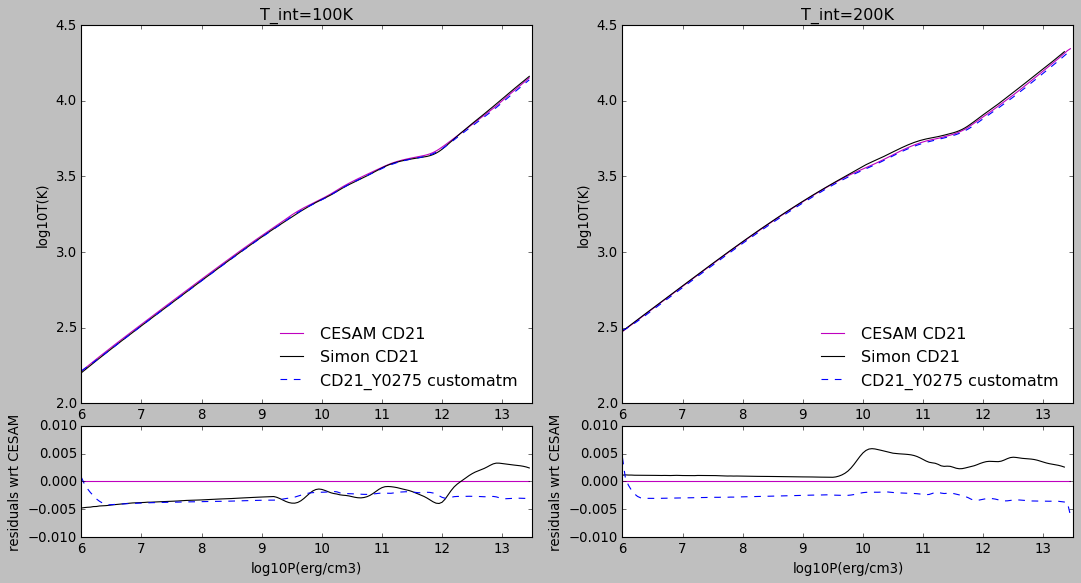

In [79]:
fig = plt.figure(figsize=(16,8))
gs = gridspec.GridSpec(4,2)
ax00 = plt.subplot(gs[0:3,0])
ax01 = plt.subplot(gs[0:3,1])
ax10 = plt.subplot(gs[3,0])
ax11 = plt.subplot(gs[3,1])

ax00.plot(desired_log10P,cesam_t100_interp_logT,'m-',label='CESAM CD21')
ax00.plot(desired_log10P,simon_t100_interp_logT,'k-',label='Simon CD21')

ax01.plot(desired_log10P,cesam_t200_interp_logT,'m-',label='CESAM CD21')
ax01.plot(desired_log10P,simon_t200_interp_logT,'k-',label='Simon CD21')

ax10.plot(desired_log10P,cesam_t100_interp_logT/cesam_t100_interp_logT - 1,'m-',label='CESAM CD21')
ax10.plot(desired_log10P,simon_t100_interp_logT/cesam_t100_interp_logT - 1,'k-',label='Simon CD21')

ax11.plot(desired_log10P,cesam_t200_interp_logT/cesam_t200_interp_logT - 1,'m-',label='CESAM CD21')
ax11.plot(desired_log10P,simon_t200_interp_logT/cesam_t200_interp_logT - 1,'k-',label='Simon CD21')


for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        profile_history = concatenate_profiles(profile_directory="../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/LOGS/".format(e),profile_prefix="planet_5.0Gyr_1.0_Mj_{0}_Rj_platowg_{1}".format(r,a))
        #print(profile_history)

        t100_idxs = find_T_int(profile_history, T_int=100)
        t200_idxs = find_T_int(profile_history, T_int=200)

        print(profile_history['T_int'][t100_idxs])
        print(profile_history['T_int'][t200_idxs])


        t100_interp_logT = np.interp(desired_log10P, profile_history['logP'][t100_idxs], profile_history['logT'][t100_idxs])
        t200_interp_logT = np.interp(desired_log10P, profile_history['logP'][t200_idxs], profile_history['logT'][t200_idxs])

        ax00.plot(desired_log10P,t100_interp_logT,color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))

        ax01.plot(desired_log10P,t200_interp_logT,color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))

        ax10.plot(desired_log10P,t100_interp_logT/cesam_t100_interp_logT - 1,color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))

        ax11.plot(desired_log10P,t200_interp_logT/cesam_t200_interp_logT - 1,color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))



ax00.set_ylabel('log10T(K)')
ax00.legend(loc='lower right',frameon=False)
ax00.set_title("T_int=100K")

ax01.set_ylabel('log10T(K)')
ax01.legend(loc='lower right',frameon=False)
ax01.set_title("T_int=200K")

ax10.set_ylabel('residuals wrt CESAM')

ax11.set_ylabel('residuals wrt CESAM')


for ax in [ax00,ax01,ax10,ax11]:
    ax.set_xlabel('log10P(erg/cm3)')
    ax.set_xlim(6,13.5)

for ax in [ax10,ax11]:
    ax.set_ylim(-0.01,0.01)
plt.show()

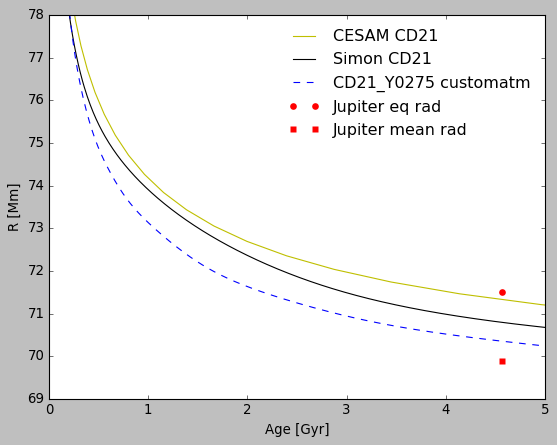

In [80]:
rJ_eq = 7.15e7 #m
rJ_mean = 6.99e7 #m

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(cesam['age[Myr]'][cesam_outermost_mask]/1.e3,cesam['R[cm]'][cesam_outermost_mask]/1.e8,'y-',label='CESAM CD21')
ax.plot(simon_history['Age(yr)']/1.e9,simon_history['Radius(cm)']/1.e8,'k-',label='Simon CD21')

for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        history =Table.read("../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_Rj_platowg_{2}.history".format(e,r,a), format="ascii", header_start=4, data_start=5)

        ax.plot(history['star_age']/1.e9,(history['radius']*rsun_to_cm)/1.e8,color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))

ax.set_xlim(0,5)
ax.set_ylim(69,78)

ax.set_xlabel("Age [Gyr]")
ax.set_ylabel("R [Mm]")
ax.plot(4.568, rJ_eq/1.e6,'ro',mec='None',label='Jupiter eq rad')
ax.plot(4.568, rJ_mean/1.e6,'rs',mec='None',label='Jupiter mean rad')

ax.legend(loc='upper right',frameon=False)
plt.show()

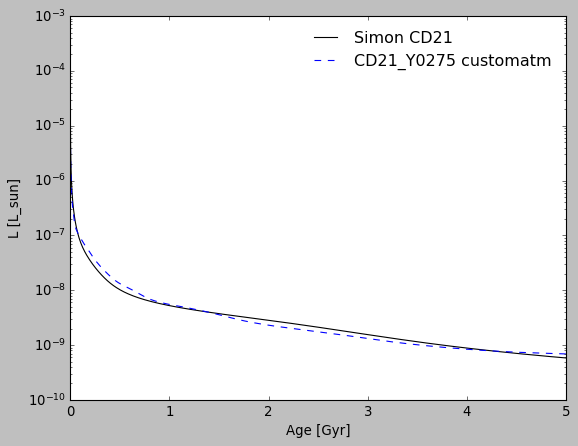

In [81]:
Lsun = 3.828e33 #erg/s

cesam_R_cm = cesam['R[cm]'][cesam_outermost_mask]
cesam_T_K = cesam['T[K]'][cesam_outermost_mask]
cesam_L_cgs = 4*np.pi*cesam_R_cm**2*cesam_T_K**4 * 5.670e-5

fig, ax = plt.subplots(1,1,figsize=(8,6))
#ax.plot(cesam['age[Myr]'][cesam_outermost_mask]/1.e3,cesam_L_cgs/Lsun,'m-',label='CESAM CD21')
ax.plot(simon_history['Age(yr)']/1.e9,simon_history['Luminosity(erg/s)']/Lsun,'k-',label='Simon CD21')

for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        history =Table.read("../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_Rj_platowg_{2}.history".format(e,r,a), format="ascii", header_start=4, data_start=5)

        ax.plot(history['star_age']/1.e9,history['luminosity'],color=eos_colors[i],ls=atm_ls[j],label='{0} {1}'.format(e,a))

ax.set_xlim(0,5)
ax.set_yscale('log')
ax.legend(loc='upper right',frameon=False)
ax.set_xlabel("Age [Gyr]")
ax.set_ylabel("L [L_sun]")
plt.show()

In [82]:
# Save to file

In [83]:
for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        print(e,a)
        profile_history = concatenate_profiles(profile_directory="../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/LOGS/".format(e),profile_prefix="planet_5.0Gyr_1.0_Mj_{0}_Rj_platowg_{1}".format(r,a))
        #print(profile_history)

        if a=="irradiatedgrey":
            savefilename = "./MESA_interior_CD21_Y0275_platowg_irradiatedgrey.data"
        elif a=="customatm":
            savefilename = "./MESA_interior_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot.data".format(r)

        to_save = profile_history['model_number','age(yr)','T_int','logP','logT','tau','grada']

            
        ascii.write(to_save,savefilename,overwrite=True)

CD21_Y0275 customatm


In [84]:
for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        history =Table.read("../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_Rj_platowg_{2}.history".format(e,r,a), format="ascii", header_start=4, data_start=5)

        
        if a=="irradiatedgrey":
            savefilename = "./MESA_evolution_CD21_Y0275_platowg_irradiatedgrey_prelim.data"
        elif a=="customatm":
            savefilename = "./MESA_evolution_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot_prelim.data".format(r)


        to_save_prelim = history['model_number','star_age','luminosity','radius']
        print(history.colnames)
        ascii.write(to_save_prelim,savefilename,overwrite=True)

['model_number', 'num_zones', 'star_age', 'log_dt', 'Teff', 'luminosity', 'radius', 'log_g', 'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'center_entropy', 'tot_E', 'rel_run_E_err', 'rel_E_err', 'num_retries', 'num_iters']


In [85]:
def interpolate_Tint(prelim_history_file, profile_history_file):
    profile_history = Table.read(profile_history_file, format="ascii", header_start=0, data_start=1)
    print(profile_history.colnames)
    history = Table.read(prelim_history_file, format="ascii", header_start=0, data_start=1)
    print(history.colnames)

    desired_ages = np.array(history['star_age'])

    age_jump = np.array(profile_history['age(yr)'])[1:] - np.array(profile_history['age(yr)'])[0:-1]
    age_jump = np.concatenate((np.atleast_1d(np.array((0))),age_jump))

    age_jump_mask = (age_jump > 0)
    
    first_entry_each_model_idxs = np.arange(len(age_jump_mask))[age_jump_mask]
    first_entry_each_model_idxs = np.concatenate((np.atleast_1d(np.array((0))),first_entry_each_model_idxs))
    #print(profile_history[first_entry_each_model_idxs])

    known_ages = profile_history['age(yr)'][first_entry_each_model_idxs]
    known_Tint =  profile_history['T_int'][first_entry_each_model_idxs]

    interp = make_interp_spline(np.log10(known_ages), known_Tint,k=1)
    #interp_Tint = np.interp(desired_ages, known_ages, known_Tint)
    interp_Tint = interp(np.log10(desired_ages))

    print(len(desired_ages))
    print(len(interp_Tint))

    fig, ax = plt.subplots(1,1,figsize=(8,6))
    ax.plot(known_ages,known_Tint,'ro')
    ax.plot(desired_ages,interp_Tint,'k-')
    #ax.set_xscale('log')
    plt.show()
    
    return interp_Tint
    

In [86]:
#irradiatedgrey_interp_Tint = interpolate_Tint(prelim_history_file='MESA_evolution_CD21_platowg_irradiatedgrey_prelim.data',profile_history_file='MESA_interior_CD21_platowg_irradiatedgrey.data')

['model_number', 'age(yr)', 'T_int', 'logP', 'logT', 'tau', 'grada']
['model_number', 'star_age', 'luminosity', 'radius']
566
566


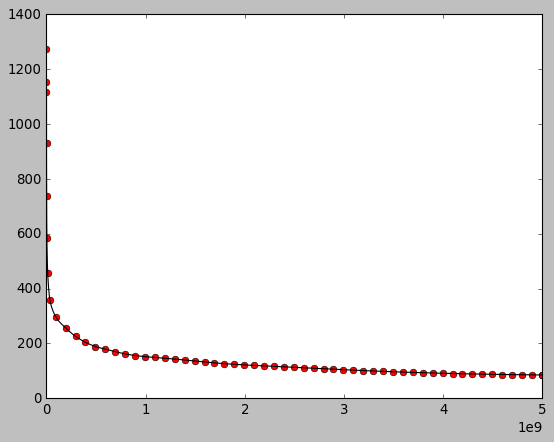

In [87]:
customatm_interp_Tint = interpolate_Tint(prelim_history_file='MESA_evolution_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot_prelim.data'.format(r),profile_history_file='MESA_interior_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot.data'.format(r))


In [88]:
'''
ig_prelim_history = Table.read('MESA_evolution_CD21_platowg_irradiatedgrey_prelim.data', format="ascii", header_start=0, data_start=1)

ig_prelim_history['T_int(K)'] = irradiatedgrey_interp_Tint

ig_prelim_history['age(yr)'] = ig_prelim_history['star_age']
ig_prelim_history['radius(cm)'] = ig_prelim_history['radius']*rsun_to_cm
ig_prelim_history['luminosity(erg/s)'] = ig_prelim_history['luminosity']*Lsun


to_save = ig_prelim_history['model_number','age(yr)','T_int(K)','luminosity(erg/s)','radius(cm)']
print(to_save)

ascii.write(to_save,'MESA_evolution_CD21_platowg_irradiatedgrey.data',overwrite=True)
'''

'\nig_prelim_history = Table.read(\'MESA_evolution_CD21_platowg_irradiatedgrey_prelim.data\', format="ascii", header_start=0, data_start=1)\n\nig_prelim_history[\'T_int(K)\'] = irradiatedgrey_interp_Tint\n\nig_prelim_history[\'age(yr)\'] = ig_prelim_history[\'star_age\']\nig_prelim_history[\'radius(cm)\'] = ig_prelim_history[\'radius\']*rsun_to_cm\nig_prelim_history[\'luminosity(erg/s)\'] = ig_prelim_history[\'luminosity\']*Lsun\n\n\nto_save = ig_prelim_history[\'model_number\',\'age(yr)\',\'T_int(K)\',\'luminosity(erg/s)\',\'radius(cm)\']\nprint(to_save)\n\nascii.write(to_save,\'MESA_evolution_CD21_platowg_irradiatedgrey.data\',overwrite=True)\n'

In [89]:
sg_prelim_history = Table.read('MESA_evolution_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot_prelim.data'.format(r), format="ascii", header_start=0, data_start=1)

sg_prelim_history['T_int(K)'] = customatm_interp_Tint

sg_prelim_history['age(yr)'] = sg_prelim_history['star_age']
sg_prelim_history['radius(cm)'] = sg_prelim_history['radius']*rsun_to_cm
sg_prelim_history['luminosity(erg/s)'] = sg_prelim_history['luminosity']*Lsun


to_save = sg_prelim_history['model_number','age(yr)','T_int(K)','luminosity(erg/s)','radius(cm)']
print(to_save)

ascii.write(to_save,'MESA_evolution_CD21_Y0275_{0}_Rj_platowg_simplifiedguillot.data'.format(r),overwrite=True)

model_number      age(yr)       ...   luminosity(erg/s)        radius(cm)    
------------ ------------------ ... ---------------------- ------------------
         106 1696.1189418690733 ... 2.4783918472614556e+29   13781318001.0419
         107  3731.461672111961 ... 2.4636250618365198e+29 13760771019.730152
         108  6173.872948403426 ... 2.4461059259876947e+29 13736369000.032074
         109  9104.766479953185 ...   2.42536727062648e+29   13707445486.5708
         110 12621.838717812894 ... 2.4008825449896247e+29 13673242053.031773
         111 16842.325403244544 ... 2.3720681665637804e+29 13632905436.134432
         112 21906.909425762526 ... 2.3382921347688918e+29 13585489770.530027
         113 27984.410252784102 ... 2.2988837562655254e+29  13529962726.62349
         114 35277.411245209994 ...  2.253144095689153e+29 13465218394.404259
         115  44029.01243612106 ... 2.2003913868724002e+29  13390109443.92105
         ...                ... ...                    ...      

CD21_Y0275 customatm
['zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'dm', 'q', 'xq', 'radius', 'temperature', 'energy', 'entropy', 'pressure', 'prad', 'pgas', 'grada', 'csound', 'opacity', 'luminosity', 'sch_stable', 'ledoux_stable', 'mixing_type', 'tau', 'age(yr)', 'model_number', 'P_1bar', 'zone_1bar', 'T_1bar', 'T_int']


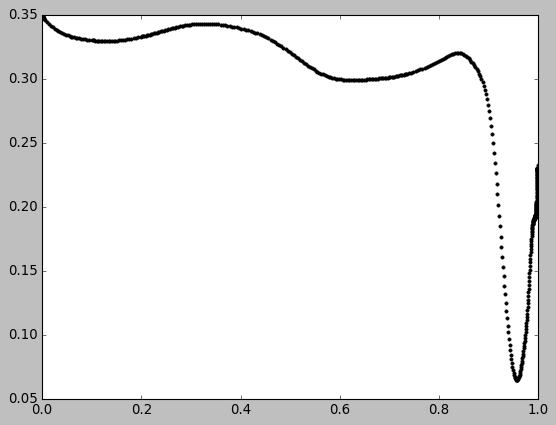

In [90]:
for i,e in enumerate(eos_names):
    for j,a in enumerate(atm):
        print(e,a)
        profile_history = concatenate_profiles(profile_directory="../MESA_EoS/thermo_consistency/MESA_runs/eos_{0}/LOGS/".format(e),profile_prefix="planet_5.0Gyr_1.0_Mj_{0}_Rj_platowg_{1}".format(r,a))
        print(profile_history.colnames)
        fig, ax = plt.subplots(1,1,figsize=(8,6))
        ax.plot(profile_history['q'][-500:],profile_history['grada'][-500:],'k.')
        plt.show()

In [84]:
r = 2.0

In [85]:
old = Table.read('MESA_evolution_CD21_platowg_simplifiedguillot.data', format="ascii", header_start=0, data_start=1)

new = Table.read('MESA_evolution_CD21_{0}_Rj_platowg_simplifiedguillot.data'.format(r), format="ascii", header_start=0, data_start=1)


print(old.colnames)
print(new.colnames)

['model_number', 'age(yr)', 'T_int(K)', 'luminosity(erg/s)', 'radius(cm)']
['model_number', 'age(yr)', 'T_int(K)', 'luminosity(erg/s)', 'radius(cm)']


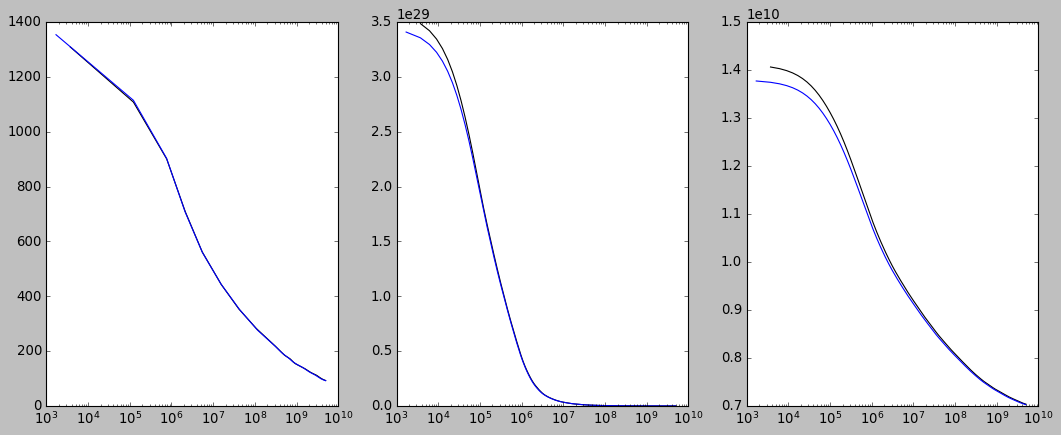

In [86]:
fig, axes = plt.subplots(1,3,figsize=(16,6))

axes[0].plot(old['age(yr)'],old['T_int(K)'],'k-')
axes[0].plot(new['age(yr)'],new['T_int(K)'],'b-')

axes[1].plot(old['age(yr)'],old['luminosity(erg/s)'],'k-')
axes[1].plot(new['age(yr)'],new['luminosity(erg/s)'],'b-')

axes[2].plot(old['age(yr)'],old['radius(cm)'],'k-')
axes[2].plot(new['age(yr)'],new['radius(cm)'],'b-')

for ax in axes:
    ax.set_xscale('log')
plt.show()
    

In [87]:
old = Table.read('MESA_interior_CD21_platowg_simplifiedguillot.data', format="ascii", header_start=0, data_start=1)

new = Table.read('MESA_interior_CD21_{0}_Rj_platowg_simplifiedguillot.data'.format(r), format="ascii", header_start=0, data_start=1)


print(old.colnames)
print(new.colnames)

['model_number', 'age(yr)', 'T_int(K)', 'logP(erg/cm3)', 'logT(K)', 'tau']
['model_number', 'age(yr)', 'T_int(K)', 'logP(erg/cm3)', 'logT(K)', 'tau']


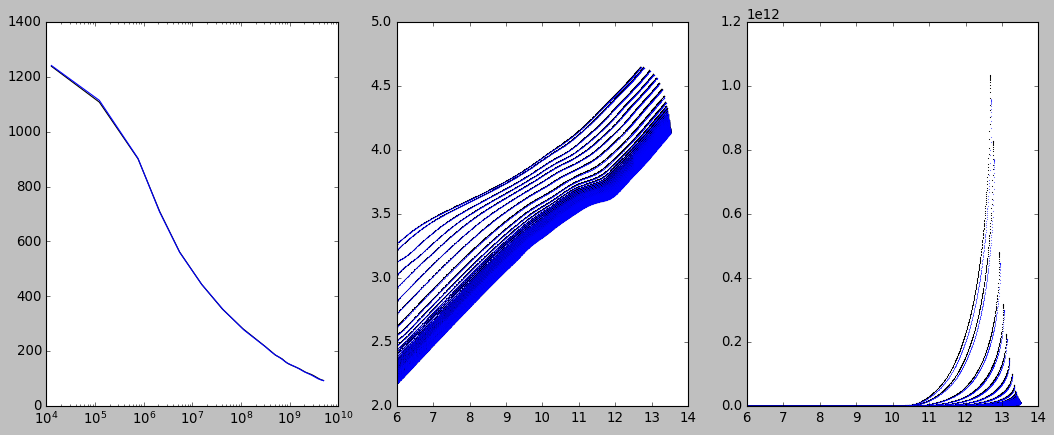

In [91]:
fig, axes = plt.subplots(1,3,figsize=(16,6))

axes[0].plot(old['age(yr)'],old['T_int(K)'],'k-')
axes[0].plot(new['age(yr)'],new['T_int(K)'],'b-')
axes[0].set_xscale('log')

axes[1].plot(old['logP(erg/cm3)'],old['logT(K)'],'k.',ms=1)
axes[1].plot(new['logP(erg/cm3)'],new['logT(K)'],'b.',ms=1,alpha=0.5)

axes[2].plot(old['logP(erg/cm3)'],old['tau'],'k.',ms=1)
axes[2].plot(new['logP(erg/cm3)'],new['tau'],'b.',ms=1,alpha=0.5)


plt.show()
    